In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset=pd.read_csv('Mall_Customers.csv')

In [3]:
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
dataset.shape

(200, 5)

In [5]:
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
dataset.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Data Visualization Code

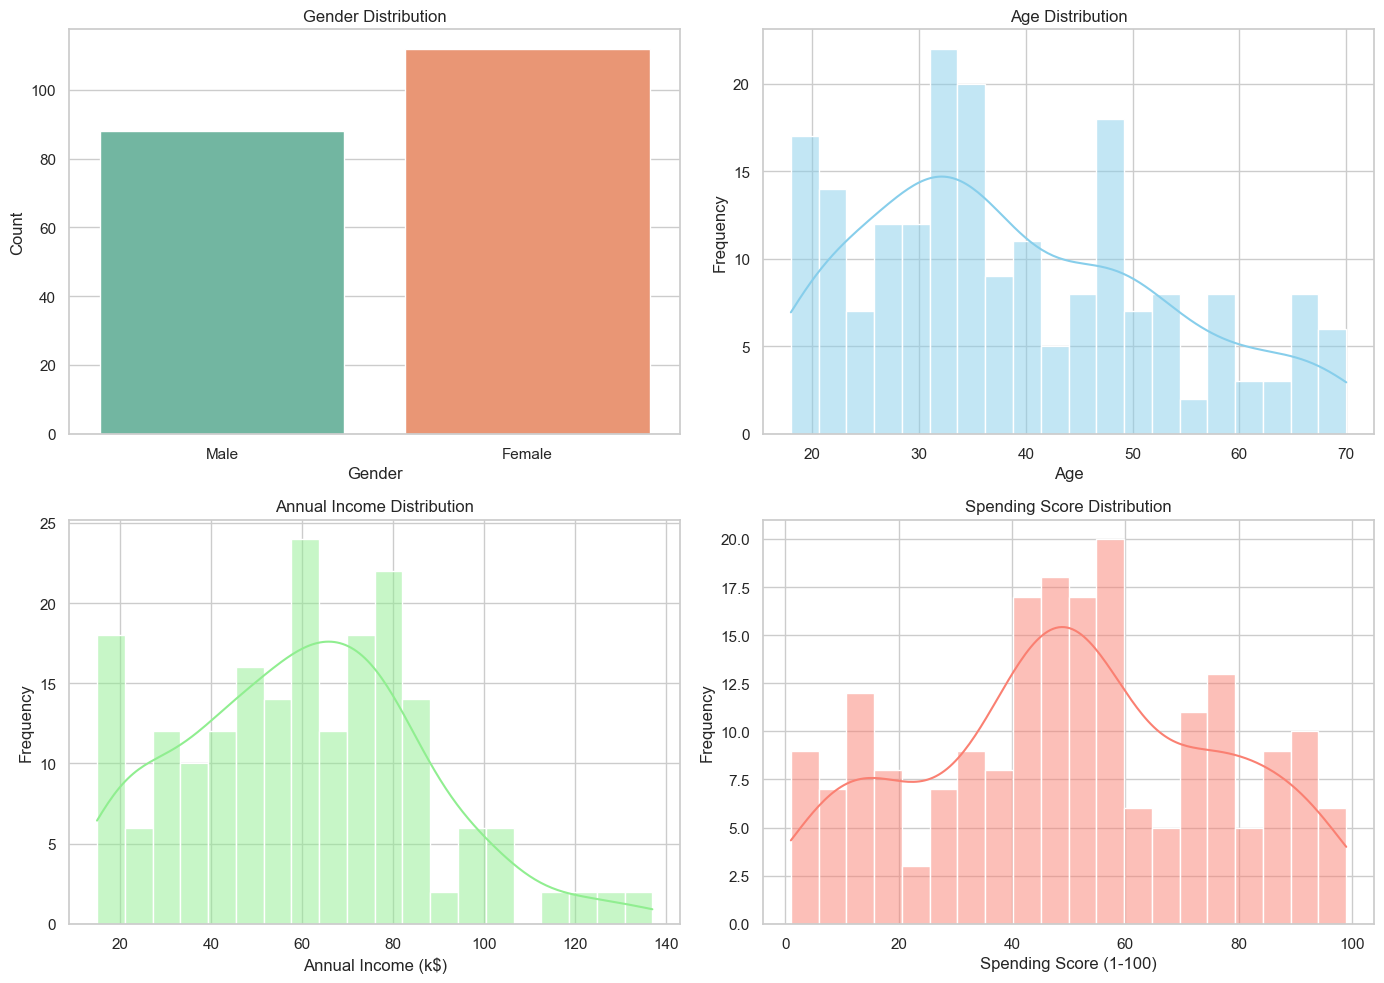

In [8]:
# Set the visualization style
sns.set_theme(style="whitegrid")

# Create a figure and a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gender Distribution (Categorical)
sns.countplot(data=dataset, x='Gender', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Gender Distribution')
axes[0, 0].set_ylabel('Count')

# 2. Age Distribution (Numerical)
sns.histplot(data=dataset, x='Age', kde=True, bins=20, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_ylabel('Frequency')

# 3. Annual Income Distribution (Numerical)
sns.histplot(data=dataset, x='Annual Income (k$)', kde=True, bins=20, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Annual Income Distribution')
axes[1, 0].set_ylabel('Frequency')

# 4. Spending Score Distribution (Numerical)
sns.histplot(data=dataset, x='Spending Score (1-100)', kde=True, bins=20, ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Spending Score Distribution')
axes[1, 1].set_ylabel('Frequency')

# Adjust layout to prevent subplots from overlapping
plt.tight_layout()

# Display the visualization
plt.show()

### Data Scaling and Tramsfoming

In [9]:
dataset=dataset.drop('CustomerID' , axis=1)

In [10]:
la=LabelEncoder()
st=StandardScaler()

In [13]:
for i in dataset.select_dtypes('int'):
    dataset[i]=st.fit_transform(dataset[[i]])

In [14]:
dataset['Gender']=la.fit_transform(dataset['Gender'])

### Perfoming PCA

In [15]:
pca=PCA(n_components=2)

In [16]:
Scaled_dataset=pca.fit_transform(dataset)

In [21]:
#View how much variance is explained by your components
print(pca.explained_variance_ratio_)

[0.4095285 0.3081674]


### Models Creation 

In [23]:
km=KMeans(n_clusters=3)

In [30]:
group=km.fit_predict(Scaled_dataset)

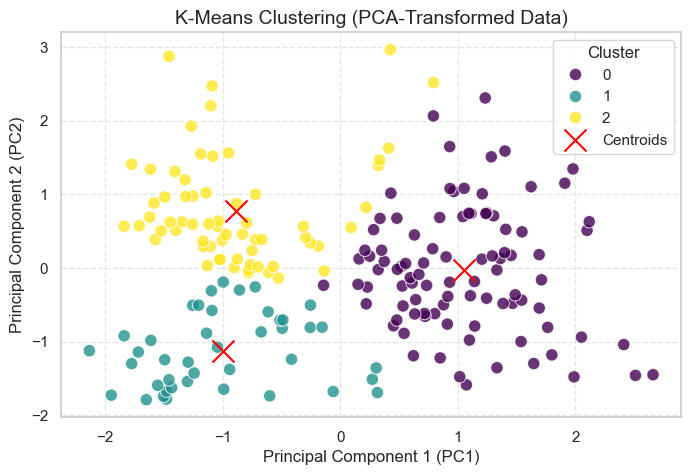

In [35]:
# 2. Set up the plot
plt.figure(figsize=(8, 5))

# 3. Create the scatter plot for the data points
sns.scatterplot(
    x=Scaled_dataset[:, 0], 
    y=Scaled_dataset[:, 1], 
    hue=group,        # Color the points by their cluster label
    palette='viridis',   # Color scheme
    s=80,                # Size of the points
    alpha=0.8            # Transparency
)

# 4. Plot the cluster centroids
centroids = km.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    c='red',             # Make centroids stand out in red
    s=250,               # Make them large
    marker='x',          # Use an X shape
    label='Centroids'
)

plt.title('K-Means Clustering (PCA-Transformed Data)', fontsize=14)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()